# Student Performance Analysis Project

This project analyzes student academic and lifestyle factors and predicts exam scores using Machine Learning.

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [5]:
from google.colab import files
import pandas as pd

# Upload dataset
uploaded = files.upload()

# Get the uploaded file name automatically
filename = list(uploaded.keys())[0]

# Load dataset
df = pd.read_csv(filename)

# Show first 5 rows
df.head()

Saving student_performance_dataset.csv.txt to student_performance_dataset.csv (1).txt


,Student_ID,Study_Hours_Per_Day,Attendance_Rate_Percentage,Sleep_Hours_Per_Day,Extracurricular_Hours_Per_Week,Stress_Level,Exam_Score,Passed
0,STU_0001,3.66,75,6.19,7,Moderate,77.19,Yes
1,STU_0002,2.84,68,6.83,0,High,73.55,Yes
2,STU_0003,3.89,66,6.05,7,High,83.84,Yes
3,STU_0004,5.52,66,6.63,5,High,100.00,Yes
4,STU_0005,2.74,66,4.73,3,High,61.27,Yes


In [6]:
df.head()

,Student_ID,Study_Hours_Per_Day,Attendance_Rate_Percentage,Sleep_Hours_Per_Day,Extracurricular_Hours_Per_Week,Stress_Level,Exam_Score,Passed
0,STU_0001,3.66,75,6.19,7,Moderate,77.19,Yes
1,STU_0002,2.84,68,6.83,0,High,73.55,Yes
2,STU_0003,3.89,66,6.05,7,High,83.84,Yes
3,STU_0004,5.52,66,6.63,5,High,100.00,Yes
4,STU_0005,2.74,66,4.73,3,High,61.27,Yes


In [7]:
df.columns

Index(['Student_ID', 'Study_Hours_Per_Day', 'Attendance_Rate_Percentage',
       'Sleep_Hours_Per_Day', 'Extracurricular_Hours_Per_Week', 'Stress_Level',
       'Exam_Score', 'Passed'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Student_ID                      1000 non-null   object 
 1   Study_Hours_Per_Day             1000 non-null   float64
 2   Attendance_Rate_Percentage      1000 non-null   int64  
 3   Sleep_Hours_Per_Day             1000 non-null   float64
 4   Extracurricular_Hours_Per_Week  1000 non-null   int64  
 5   Stress_Level                    1000 non-null   object 
 6   Exam_Score                      1000 non-null   float64
 7   Passed                          1000 non-null   object 
dtypes: float64(3), int64(2), object(3)
memory usage: 62.6+ KB


In [9]:
df.isnull().sum()

,0
Student_ID,0
Study_Hours_Per_Day,0
Attendance_Rate_Percentage,0
Sleep_Hours_Per_Day,0
Extracurricular_Hours_Per_Week,0
Stress_Level,0
Exam_Score,0
Passed,0


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.dtypes

,0
Student_ID,object
Study_Hours_Per_Day,float64
Attendance_Rate_Percentage,int64
Sleep_Hours_Per_Day,float64
Extracurricular_Hours_Per_Week,int64
Stress_Level,object
Exam_Score,float64
Passed,object


In [12]:
df.describe()

,Study_Hours_Per_Day,Attendance_Rate_Percentage,Sleep_Hours_Per_Day,Extracurricular_Hours_Per_Week,Exam_Score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,3.270720,63.173000,7.008300,6.954000,75.176710
std,1.356257,9.371814,1.172261,4.270143,14.378376
min,0.820000,40.000000,4.000000,0.000000,32.790000
25%,2.320000,57.000000,6.220000,3.000000,64.622500
50%,3.035000,62.000000,7.000000,7.000000,74.060000
75%,3.890000,69.000000,7.792500,11.000000,85.117500
max,12.000000,100.000000,11.000000,14.000000,100.000000


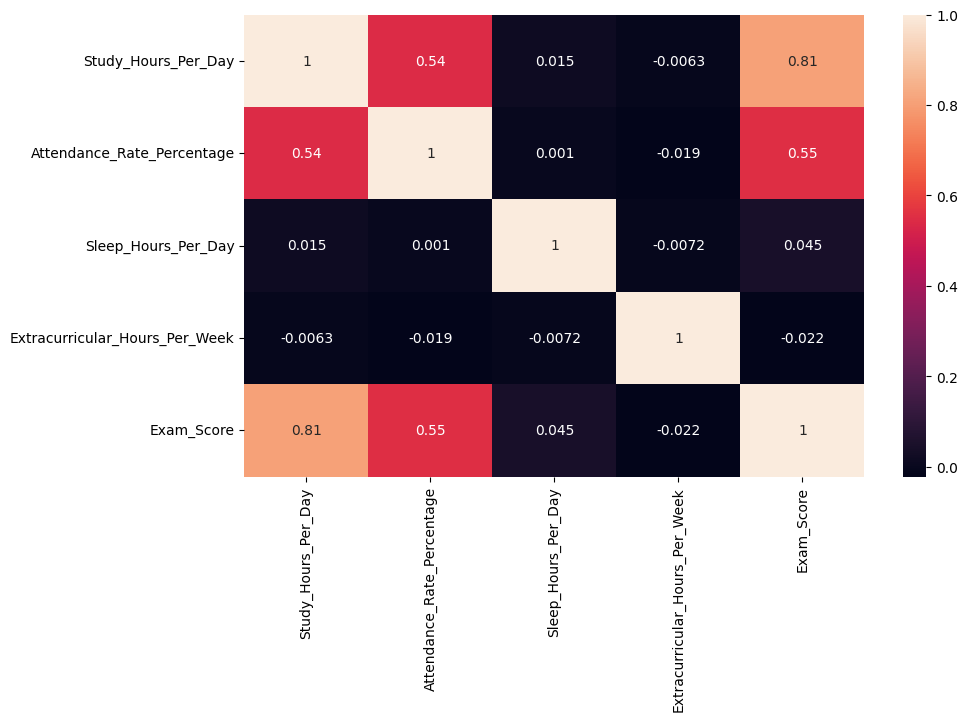

In [13]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [14]:
df.columns

Index(['Student_ID', 'Study_Hours_Per_Day', 'Attendance_Rate_Percentage',
       'Sleep_Hours_Per_Day', 'Extracurricular_Hours_Per_Week', 'Stress_Level',
       'Exam_Score', 'Passed'],
      dtype='object')

In [15]:
X = df.drop(["Student_ID", "Exam_Score", "Passed"], axis=1)

y = df["Exam_Score"]


In [16]:
X.head()

,Study_Hours_Per_Day,Attendance_Rate_Percentage,Sleep_Hours_Per_Day,Extracurricular_Hours_Per_Week,Stress_Level
0,3.66,75,6.19,7,Moderate
1,2.84,68,6.83,0,High
2,3.89,66,6.05,7,High
3,5.52,66,6.63,5,High
4,2.74,66,4.73,3,High


In [17]:
y.head()

,Exam_Score
0,77.19
1,73.55
2,83.84
3,100.00
4,61.27


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(800, 5)
(200, 5)
(800,)
(200,)


In [20]:
from sklearn.linear_model import LinearRegression

In [21]:
X.dtypes

,0
Study_Hours_Per_Day,float64
Attendance_Rate_Percentage,int64
Sleep_Hours_Per_Day,float64
Extracurricular_Hours_Per_Week,int64
Stress_Level,object


In [22]:
X = pd.get_dummies(X, columns=["Stress_Level"], drop_first=True)

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [25]:
y_pred = model.predict(X_test)

y_pred[:5]

array([82.911309  , 83.8666637 , 59.14929407, 69.20287176, 65.43298247])

In [26]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 6.436109986939473
MSE: 76.78747312190723
R2 Score: 0.6173374965429581


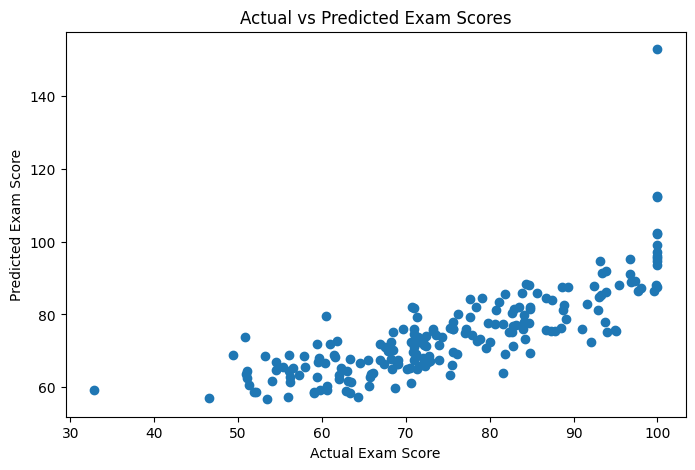

In [27]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")

plt.title("Actual vs Predicted Exam Scores")

plt.show()

In [28]:
prediction = model.predict(X_test.iloc[[0]])

print("Predicted Exam Score:", prediction[0])
print("Actual Exam Score:", y_test.iloc[0])

Predicted Exam Score: 82.91130900439845
Actual Exam Score: 91.59


In [29]:
import pickle

with open("student_performance_model.pkl", "wb") as file:
    pickle.dump(model, file)

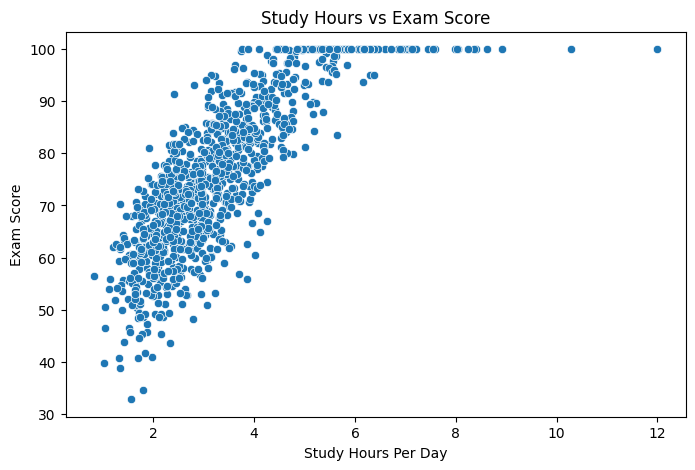

In [30]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Study_Hours_Per_Day",
    y="Exam_Score",
    data=df
)

plt.title("Study Hours vs Exam Score")
plt.xlabel("Study Hours Per Day")
plt.ylabel("Exam Score")

plt.show()

In [31]:
## Model Evaluation - RMSE

In [32]:
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE:", rmse)


RMSE: 8.7628461770082


In [33]:
## Student Performance Prediction System

In [34]:
df["Stress_Level"].unique()

array(['Moderate', 'High', 'Low'], dtype=object)

In [35]:
try:

    study_hours = float(input("Enter study hours per day: "))
    attendance = float(input("Enter attendance percentage: "))
    sleep_hours = float(input("Enter sleep hours per day: "))
    extra_hours = float(input("Enter extracurricular hours per week: "))
    stress = input("Enter stress level (Low/Medium/High): ")


    new_student = pd.DataFrame({
    "Study_Hours_Per_Day": [study_hours],
    "Attendance_Rate_Percentage": [attendance],
    "Sleep_Hours_Per_Day": [sleep_hours],
    "Extracurricular_Hours_Per_Week": [extra_hours],
    "Stress_Level_Low": [1 if stress.lower() == "low" else 0],
    "Stress_Level_Moderate": [1 if stress.lower() == "moderate" else 0]
})

    prediction = model.predict(new_student)

    print("Predicted Exam Score:", prediction[0])


except Exception as e:
    print("Error:", e)


Enter study hours per day: 4
Enter attendance percentage: 80
Enter sleep hours per day: 7
Enter extracurricular hours per week: 2
Enter stress level (Low/Medium/High): LOW
Predicted Exam Score: 77.69980051833414


In [36]:
X.columns

Index(['Study_Hours_Per_Day', 'Attendance_Rate_Percentage',
       'Sleep_Hours_Per_Day', 'Extracurricular_Hours_Per_Week',
       'Stress_Level_Low', 'Stress_Level_Moderate'],
      dtype='object')

In [37]:
study_hours = float(input("Enter study hours per day: "))
attendance = float(input("Enter attendance percentage: "))
sleep_hours = float(input("Enter sleep hours per day: "))
extra_hours = float(input("Enter extracurricular hours per week: "))
stress = input("Enter stress level (Low/Medium/High): ")


new_student = pd.DataFrame({
    "Study_Hours_Per_Day": [study_hours],
    "Attendance_Rate_Percentage": [attendance],
    "Sleep_Hours_Per_Day": [sleep_hours],
    "Extracurricular_Hours_Per_Week": [extra_hours],
    "Stress_Level_Low": [1 if stress == "Low" else 0],
    "Stress_Level_Moderate": [1 if stress == "Moderate" else 0] # Corrected from Stress_Level_Medium
})
prediction = model.predict(new_student)

print("Predicted Exam Score:", prediction[0])

Enter study hours per day: 6
Enter attendance percentage: 90
Enter sleep hours per day: 8
Enter extracurricular hours per week: 3
Enter stress level (Low/Medium/High): high
Predicted Exam Score: 103.92549817463286


In [38]:
print(df.columns)

Index(['Student_ID', 'Study_Hours_Per_Day', 'Attendance_Rate_Percentage',
       'Sleep_Hours_Per_Day', 'Extracurricular_Hours_Per_Week', 'Stress_Level',
       'Exam_Score', 'Passed'],
      dtype='object')


In [39]:
df['Extracurricular_Hours_Per_Week'].describe()

,Extracurricular_Hours_Per_Week
count,1000.000000
mean,6.954000
std,4.270143
min,0.000000
25%,3.000000
50%,7.000000
75%,11.000000
max,14.000000


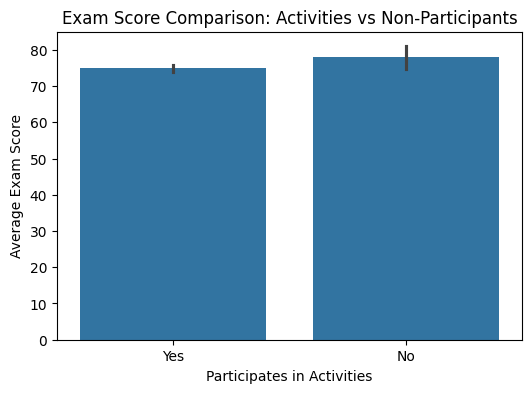

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create activity participation column
df['Participates_In_Activities'] = df['Extracurricular_Hours_Per_Week'].apply(
    lambda x: 'Yes' if x > 0 else 'No'
)

# Create bar chart
plt.figure(figsize=(6,4))
sns.barplot(
    data=df,
    x='Participates_In_Activities',
    y='Exam_Score'
)

plt.title('Exam Score Comparison: Activities vs Non-Participants')
plt.xlabel('Participates in Activities')
plt.ylabel('Average Exam Score')
plt.show()